In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr


In [2]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
from taylor_setup import *

In [3]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

In [4]:
# %% 10. Load-only cell: usable in a fresh kernel without rerunning the calculations
# Only load pickle-containing .npy dictionaries that you created/trust.
import numpy as np
from pathlib import Path

overlap_save_dir        = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
overlap_member_values   = np.load(overlap_save_dir / "overlap_member_values.npy", allow_pickle=True).item()
overlap_model_means     = np.load(overlap_save_dir / "overlap_model_means.npy", allow_pickle=True).item()
overlap_MMM             = np.load(overlap_save_dir / "overlap_MMM.npy", allow_pickle=True).item()
overlap_observations    = np.load(overlap_save_dir / "overlap_observations.npy", allow_pickle=True).item()
overlap_model_n_valid   = np.load(overlap_save_dir / "overlap_model_n_valid.npy", allow_pickle=True).item()
overlap_MMM_n_valid     = np.load(overlap_save_dir / "overlap_MMM_n_valid.npy", allow_pickle=True).item()
overlap_model_names     = np.load(overlap_save_dir / "overlap_model_names.npy", allow_pickle=True).item()
overlap_member_ids      = np.load(overlap_save_dir / "overlap_member_ids.npy", allow_pickle=True).item()
overlap_coordinates     = np.load(overlap_save_dir / "overlap_coordinates.npy", allow_pickle=True).item()
overlap_quantity_info   = np.load(overlap_save_dir / "overlap_quantity_info.npy", allow_pickle=True).item()
overlap_sources         = np.load(overlap_save_dir / "overlap_sources.npy", allow_pickle=True).item()
overlap_metadata        = np.load(overlap_save_dir / "overlap_metadata.npy", allow_pickle=True).item()

overlap_score_save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs")
# The first three containers use [experiment][quantity][model][score].
overlap_member_scores = np.load(overlap_score_save_dir / "overlap_member_scores.npy", allow_pickle=True).item()
overlap_mean_member_scores = np.load(overlap_score_save_dir / "overlap_mean_member_scores.npy", allow_pickle=True).item()
overlap_model_mean_scores = np.load(overlap_score_save_dir / "overlap_model_mean_scores.npy", allow_pickle=True).item()
# The two MMM containers use [experiment][quantity][score], without a model key.
overlap_MMM_scores = np.load(overlap_score_save_dir / "overlap_MMM_scores.npy", allow_pickle=True).item()
overlap_MMM_mean_member_scores = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_scores.npy", allow_pickle=True).item()

overlap_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_MMM_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_score_model_names = np.load(overlap_score_save_dir / "overlap_score_model_names.npy", allow_pickle=True).item()
overlap_score_member_ids = np.load(overlap_score_save_dir / "overlap_score_member_ids.npy", allow_pickle=True).item()
overlap_score_metadata = np.load(overlap_score_save_dir / "overlap_score_metadata.npy", allow_pickle=True).item()

In [5]:
# %% 3. Load-only cell — only load pickle-containing files that you trust
import numpy as np
from pathlib import Path

decomposition_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs/pattern_decomposition")
overlap_member_decomposition = np.load(decomposition_dir / "overlap_member_decomposition.npy", allow_pickle=True).item()
overlap_mean_member_decomposition = np.load(decomposition_dir / "overlap_mean_member_decomposition.npy", allow_pickle=True).item()
overlap_MMM_mean_member_decomposition = np.load(decomposition_dir / "overlap_MMM_mean_member_decomposition.npy", allow_pickle=True).item()
overlap_decomposition_metadata = np.load(decomposition_dir / "overlap_decomposition_metadata.npy", allow_pickle=True).item()


In [6]:
# %% 1. Reconstruct each member's residual map from its OWN saved spatial fit
import numpy as np
from copy import deepcopy

# Run after loading the core overlap archive and the pattern-decomposition archive.
# Required core inputs: overlap_member_values, overlap_observations,
# overlap_member_ids, and overlap_coordinates. The fit inputs are
# overlap_member_decomposition and overlap_decomposition_metadata.
# No new detrending, temporal regression, fitting, or ensemble averaging occurs.
residual_quantities = list(overlap_decomposition_metadata["quantities"])
# residual_quantities = ["corr_Ti_R", "cov_Zi_R"]  # Optional smaller selection.

# Reuse the FITTING domain, not a newer plotting mask. Orthogonality and the
# zero-mean identity apply on this domain, with paired finite cells per member.
residual_score_metadata = overlap_decomposition_metadata["source_score_metadata"]
residual_weights = np.ma.asarray(residual_score_metadata["map_weights"], dtype=float).filled(np.nan)
residual_mask = np.ma.asarray(residual_score_metadata["map_mask"], dtype=bool).filled(False)
for coordinate in ["time", "lat", "lon"]:
    np.testing.assert_array_equal(overlap_coordinates[coordinate],
                                  residual_score_metadata["coordinates"][coordinate],
                                  err_msg=f"The {coordinate} order differs between maps and fits.")
residual_shape = (len(overlap_coordinates["lat"]), len(overlap_coordinates["lon"]))
if residual_weights.shape != residual_shape or residual_mask.shape != residual_shape:
    raise ValueError("Saved fitting weights and mask must match the (lat, lon) grid.")
if np.any(np.isfinite(residual_weights) & (residual_weights < 0)):
    raise ValueError("Saved fitting weights cannot be negative.")
residual_support = residual_mask & np.isfinite(residual_weights) & (residual_weights > 0)
if not residual_support.any():
    raise ValueError("No positive-weight cells remain in the saved fitting domain.")

# Keep the familiar experiment -> quantity -> model hierarchy. Each output is
# (member, lat, lon), in the same member order as the original maps and fits.
# historical_matched remains a separate experiment; no means are subtracted
# across members, models, or time in this calculation.
overlap_member_residual_maps = {}
for experiment, quantity_fits in overlap_member_decomposition.items():
    overlap_member_residual_maps[experiment] = {}
    for quantity in residual_quantities:
        x = np.ma.asarray(overlap_observations[quantity], dtype=float).filled(np.nan)
        if x.shape != residual_shape:
            raise ValueError(f"{quantity}: observed map must match the saved (lat, lon) grid.")
        overlap_member_residual_maps[experiment][quantity] = {}

        for model, fit in quantity_fits[quantity].items():
            y = np.ma.asarray(overlap_member_values[experiment][quantity][model], dtype=float).filled(np.nan)
            gain, offset = [np.asarray(fit[key], dtype=float) for key in ["gain", "offset"]]
            member_ids = overlap_member_ids[experiment][model]
            np.testing.assert_array_equal(member_ids, overlap_decomposition_metadata["member_ids"][experiment][model],
                                          err_msg=f"{experiment}/{model}: map and fit member labels differ.")
            if y.shape != (len(member_ids),) + residual_shape or gain.shape != (len(member_ids),) or offset.shape != gain.shape:
                raise ValueError(f"{experiment}/{quantity}/{model}: map and coefficient shapes disagree.")

            # Broadcast one gain/intercept per member over its spatial grid:
            # e_i = y_i - a*x_i - b. This is the FULL fit, so do not subtract
            # the total mean bias in place of the intercept, or weight e_i by area.
            # Missing/zero-weight cells and undefined fits remain NaN.
            valid_fit = np.isfinite(gain) & np.isfinite(offset)
            valid_cells = residual_support[None, :, :] & np.isfinite(x)[None, :, :] & np.isfinite(y)
            valid_cells &= valid_fit[:, None, None]
            residual = y - gain[:, None, None] * x[None, :, :] - offset[:, None, None]
            overlap_member_residual_maps[experiment][quantity][model] = np.where(valid_cells, residual, np.nan)
        print(f"Residual maps: {experiment} / {quantity} ({len(quantity_fits[quantity])} models)")

# Keep coordinates, member labels, units, weights, and fit provenance alongside
# the maps for later saving. No observation residual or model/MMM mean is added.
overlap_residual_map_metadata = {
    "quantities": residual_quantities.copy(),
    "quantity_info": {q: deepcopy(residual_score_metadata["quantity_info"][q]) for q in residual_quantities},
    "coordinates": {k: np.asarray(overlap_coordinates[k]).copy() for k in ["lat", "lon"]},
    "model_names": {e: {q: list(models) for q, models in quantities.items()}
                    for e, quantities in overlap_member_residual_maps.items()},
    "member_ids": deepcopy(overlap_decomposition_metadata["member_ids"]),
    "map_weights": residual_weights.copy(), "map_mask": residual_mask.copy(),
    "source_decomposition_metadata": deepcopy(overlap_decomposition_metadata),
    "definition": "e_i = model_i - gain*obs_i - offset; one saved spatial fit per member",
    "shape": "[experiment][quantity][model] -> (member, lat, lon)",
    "units": "Same physical or dimensionless units as each input diagnostic; not normalized or area-multiplied",
    "missing": "NaN outside saved fitting support, outside paired finite cells, or for an undefined fit",
}




Residual maps: amip_hist / corr_Ti_Ri (16 models)
Residual maps: amip_hist / corr_T_Ri (16 models)
Residual maps: amip_hist / corr_Ti_R (16 models)
Residual maps: amip_hist / sigma_Ti (16 models)
Residual maps: amip_hist / sigma_Ri (16 models)
Residual maps: amip_hist / cov_Zi_R (16 models)
Residual maps: amip_hist / cov_Ti_R (16 models)
Residual maps: amip_hist / cov_T_Qi (16 models)
Residual maps: amip_hist / cov_T_Ri (16 models)
Residual maps: amip_hist / cov_Zi_Ri (16 models)
Residual maps: amip_hist / cov_Ti_Qi (16 models)
Residual maps: amip_hist / cov_Ti_Ri (16 models)
Residual maps: historical / corr_Ti_Ri (53 models)
Residual maps: historical / corr_T_Ri (53 models)
Residual maps: historical / corr_Ti_R (53 models)
Residual maps: historical / sigma_Ti (53 models)
Residual maps: historical / sigma_Ri (53 models)
Residual maps: historical / cov_Zi_R (53 models)
Residual maps: historical / cov_Ti_R (53 models)
Residual maps: historical / cov_T_Qi (53 models)
Residual maps: histor

In [7]:
# %% 2. Optional check: inspect the reconstructed fields, without refitting them
# Each member's residual should have zero weighted spatial mean and be orthogonal
# to the CENTERED observed map. Its weighted variance should equal residual_std**2.
# These checks also help catch stale coefficients or changed maps. Use the original
# fit domain here: a later ocean-only display mask need not retain zero mean.
overlap_residual_map_checks = {}
residual_check_tolerance = 1e-10      # Dimensionless tolerance after scaling by map amplitude.
for experiment, quantity_maps in overlap_member_residual_maps.items():
    overlap_residual_map_checks[experiment] = {}
    for quantity, model_maps in quantity_maps.items():
        x = np.ma.asarray(overlap_observations[quantity], dtype=float).filled(np.nan)
        overlap_residual_map_checks[experiment][quantity] = {}
        for model, residual_maps in model_maps.items():
            fit = overlap_member_decomposition[experiment][quantity][model]
            y = np.ma.asarray(overlap_member_values[experiment][quantity][model], dtype=float).filled(np.nan)
            checks = {key: np.full(len(residual_maps), np.nan) for key in
                      ["weighted_mean", "cov_obs_residual", "residual_std", "mean_scaled",
                       "cov_scaled", "variance_difference_scaled"]}
            for member, residual in enumerate(residual_maps):
                valid = np.isfinite(residual)
                if not valid.any():
                    if np.isfinite(fit["gain"][member]) and np.isfinite(fit["offset"][member]):
                        raise ValueError(f"{experiment}/{quantity}/{model}/{member}: valid fit but no residual cells.")
                    continue

                # Renormalize weights over THIS member's paired support. Scaling
                # weights first changes nothing mathematically and avoids overflow.
                w = residual_weights[valid] / residual_weights[valid].max()
                w = w / w.sum()
                xv, yv, ev = x[valid], y[member][valid], residual[valid]
                mean_e = w @ ev
                cov_xe = w @ ((xv - w @ xv) * ev)
                variance_e = w @ ((ev - mean_e)**2)
                scale = max(np.sqrt(w @ xv**2), np.sqrt(w @ yv**2), 1e-100)
                checks["weighted_mean"][member], checks["cov_obs_residual"][member] = mean_e, cov_xe
                checks["residual_std"][member] = np.sqrt(variance_e)
                checks["mean_scaled"][member], checks["cov_scaled"][member] = mean_e / scale, cov_xe / scale**2
                checks["variance_difference_scaled"][member] = (variance_e - fit["residual_std"][member]**2) / scale**2

            # NaN checks correspond to undefined fits and are not treated as passes.
            # Compare VARIANCES: a near-perfect fit can have tiny roundoff in 1-r**2.
            for key in ["mean_scaled", "cov_scaled", "variance_difference_scaled"]:
                finite = checks[key][np.isfinite(checks[key])]
                np.testing.assert_allclose(finite, 0., rtol=0., atol=residual_check_tolerance,
                                           err_msg=f"{experiment}/{quantity}/{model}: {key}; check maps, fit, weights, mask.")
            overlap_residual_map_checks[experiment][quantity][model] = checks
print("Residual checks passed for defined fits; undefined fits remain NaN.")

# Example: one member's e_i field, in the original diagnostic's units.
# overlap_member_residual_maps["historical_matched"]["cov_Zi_R"][model][0]


Residual checks passed for defined fits; undefined fits remain NaN.


In [8]:
# Average available finite values along the first axis. Locations with no
# contributors remain NaN, without warnings from entirely masked grid cells.
def mean_available(values):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    count = valid.sum(axis=0)
    total = np.where(valid, values, 0.).sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0)

overlap_model_mean_residual_maps = {}
overlap_MMM_residual_maps = {}

# Process every existing experiment separately, including historical_matched.
# First average members within each model, then average those model means.
for experiment, quantities in overlap_member_residual_maps.items():
    overlap_model_mean_residual_maps[experiment] = {}
    overlap_MMM_residual_maps[experiment] = {}

    for quantity, models in quantities.items():
        model_means = {}

        # Input: (member, lat, lon). Output: one (lat, lon) map per model.
        for model, member_maps in models.items():
            model_means[model] = mean_available(member_maps)

        overlap_model_mean_residual_maps[experiment][quantity] = model_means

        # Stack along a model axis, giving each available model one vote per cell.
        stacked_model_means = np.stack(list(model_means.values()), axis=0)
        overlap_MMM_residual_maps[experiment][quantity] = mean_available(stacked_model_means)

In [9]:
# np.save('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_member_residual_maps.npy', overlap_member_residual_maps, allow_pickle=True)
# np.save('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_residual_map_metadata.npy', overlap_residual_map_metadata, allow_pickle=True)
# np.save('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_model_mean_residual_maps.npy', overlap_model_mean_residual_maps, allow_pickle=True)
# np.save('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_MMM_residual_maps.npy', overlap_MMM_residual_maps, allow_pickle=True)


In [23]:
# %% 1. Plotting function: three residual diagnostics × three experiment groups
import numpy as np
import warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path


def plot_3x3_residual_maps(maps, lat, lon, row_titles, column_titles, *,
                              figure_title="Multimodel-mean residual patterns", colorbar_labels=None,
                              cmaps="RdBu_r", vlims=None, robust_percentile=98, number_of_levels=21, plot_method="contourf",
                              central_longitude=210, robust_masks=None, overlay_style="stipple",
                              overlay_for="significant", stipple_stride=3, stipple_size=2.0,
                              stipple_color="black", stipple_alpha=0.65, stipple_marker=".",
                              hatch_pattern="....", hatch_color="black", hatch_linewidth=0.5,
                              figsize=(18, 11.5), savepath=None, dpi=200):
    """Plot a (row, column, lat, lon) = (3, 3, n_lat, n_lon) map grid.

    Rows are diagnostics, columns are datasets/experiments. cmaps, vlims, and
    colorbar_labels apply PER ROW, so the three columns share a comparable scale.
    The function only plots supplied residuals; it recalculates no statistics.
    Values are signed residuals, not RMS or absolute errors, and are NOT clipped
    to [-1, 1] merely because the original diagnostics were correlations.
    plot_method selects contourf or pcolormesh on the same symmetric linear scale.
    Any robustness masks must describe THESE residuals, not the original maps.

    robust_masks: None; a common 2D NumPy mask; a (3, 3, lat, lon) array; or a
    nested 3×3 list whose entries are 2D masks or None. A None panel has NO overlay,
    even with overlay_for="not_significant". NaN/masked cells are never overlaid.
    Finite nonzero means True/robust; zero means False/not robust. The legacy
    name "significant" selects True cells, not a new significance calculation.

    Returns fig, axes, where axes.shape == (3, 3).
    """
    maps = np.ma.asarray(maps, dtype=float).filled(np.nan)
    lat, lon = np.asarray(lat), np.asarray(lon)
    if lat.ndim != 1 or lon.ndim != 1 or min(len(lat), len(lon)) < 2:
        raise ValueError("lat and lon must be 1D coordinates with at least two points each.")
    if not np.isfinite(lat).all() or not np.isfinite(lon).all():
        raise ValueError("lat and lon must be finite.")
    if maps.shape != (3, 3, len(lat), len(lon)):
        raise ValueError(f"maps must have shape {(3, 3, len(lat), len(lon))}; got {maps.shape}.")
    if len(row_titles) != 3 or len(column_titles) != 3:
        raise ValueError("Supply three row_titles and three column_titles.")
    if plot_method not in {"contourf", "pcolormesh"}:
        raise ValueError("plot_method must be contourf or pcolormesh.")

    # Expand scalar plotting choices to three ROW choices. Automatic color limits
    # use finite values from all three columns in that row, not separate panels.
    colorbar_labels = ["", "", ""] if colorbar_labels is None else list(colorbar_labels)
    cmaps = [cmaps] * 3 if isinstance(cmaps, (str, mpl.colors.Colormap)) else list(cmaps)
    vlims = [None] * 3 if vlims is None else ([vlims] * 3 if np.isscalar(vlims) else list(vlims))
    if len(colorbar_labels) != 3 or len(cmaps) != 3 or len(vlims) != 3:
        raise ValueError("colorbar_labels, cmaps, and vlims must each describe three rows.")
    if not 0 < robust_percentile <= 100:
        raise ValueError("robust_percentile must be in (0, 100].")
    if not isinstance(number_of_levels, (int, np.integer)) or number_of_levels < 2:
        raise ValueError("number_of_levels must be an integer of at least 2.")
    row_levels = []
    for row in range(3):
        limit = vlims[row]
        if limit is None:
            finite = np.abs(maps[row][np.isfinite(maps[row])])
            if not finite.size:
                raise ValueError(f"Row {row + 1} has no finite values; supply a manual vlim to show it blank.")
            limit = float(np.percentile(finite, robust_percentile))
            limit = float(finite.max()) if limit == 0 else limit
            limit = 1.0 if limit == 0 else limit
        if not np.isfinite(limit) or limit <= 0:
            raise ValueError("Every color limit must be positive and finite.")
        row_levels.append(np.linspace(-limit, limit, number_of_levels))

    # Prepare explicit panel masks. In particular, None for any panel means
    # "no robustness assessment supplied", not a False mask to invert/stipple.
    if overlay_style not in {"stipple", "hatch"}:
        raise ValueError("overlay_style must be 'stipple' or 'hatch'.")
    if overlay_for not in {"significant", "not_significant"}:
        raise ValueError("overlay_for must be 'significant' or 'not_significant'.")
    if not isinstance(stipple_stride, (int, np.integer)) or stipple_stride < 1:
        raise ValueError("stipple_stride must be a positive integer.")
    if robust_masks is None:
        masks = [[None] * 3 for _ in range(3)]
    elif isinstance(robust_masks, np.ndarray) and robust_masks.ndim == 2:
        masks = [[robust_masks] * 3 for _ in range(3)]
    else:
        if len(robust_masks) != 3 or any(len(row) != 3 for row in robust_masks):
            raise ValueError("robust_masks must be a 3×3 list/array of panel masks, or a common 2D NumPy mask.")
        masks = [list(row) for row in robust_masks]
    for row in range(3):
        for column in range(3):
            if masks[row][column] is not None:
                mask = np.ma.asarray(masks[row][column], dtype=float).filled(np.nan)
                if mask.shape != maps.shape[-2:]:
                    raise ValueError(f"Mask [{row}][{column}] must have shape {maps.shape[-2:]}.")
                masks[row][column] = mask
    longitude_is_cyclic = np.isclose(abs(lon[-1] - lon[0]), 360)

    # Keep your Robinson/coastline style, with a horizontal colorbar shared
    # across each row. Panel labels run a–i in ordinary row-major order.
    fig, axes = plt.subplots(3, 3, figsize=figsize,
                             subplot_kw={"projection": ccrs.Robinson(central_longitude=central_longitude)})
    # Reserve explicit title/row-colorbar space; fixed-aspect geographic axes can
    # otherwise crowd titles when a layout engine also resizes shared colorbars.
    fig.subplots_adjust(left=0.065, right=0.99, top=0.90, bottom=0.045, wspace=0.035, hspace=0.32)
    for row in range(3):
        for column in range(3):
            ax, panel_map = axes[row, column], maps[row, column]
            if longitude_is_cyclic:
                plot_map, plot_lon = panel_map, lon
            else:
                plot_map, plot_lon = add_cyclic_point(panel_map, coord=lon, axis=-1)
            norm = mpl.colors.Normalize(vmin=row_levels[row][0], vmax=row_levels[row][-1])
            # Constant/empty panels have no contour boundaries. Mesh rendering
            # avoids degenerate global contour polygons while keeping the norm.
            finite_panel = panel_map[np.isfinite(panel_map)]
            contours_drawn = False
            if plot_method == "contourf" and finite_panel.size and np.ptp(finite_panel) > 0:
                before_contours = list(ax.collections)
                try:
                    mappable = ax.contourf(plot_lon, lat, np.ma.masked_invalid(plot_map), levels=row_levels[row],
                                           norm=norm, cmap=cmaps[row], extend="both", transform=ccrs.PlateCarree())
                    contours_drawn = True
                except TypeError as error:
                    # Some Cartopy/Shapely combinations cannot project a contour
                    # polygon at the map seam. Remove only the failed new artists,
                    # warn explicitly, and draw these same values as a mesh.
                    # Other errors are not swallowed.
                    if "GeometryCollection" not in str(error):
                        raise
                    for artist in list(ax.collections):
                        if artist not in before_contours:
                            artist.remove()
                    warnings.warn(f"Panel {row + 1},{column + 1}: Cartopy contour geometry failed; using pcolormesh.",
                                  RuntimeWarning, stacklevel=2)
            if not contours_drawn:
                mappable = ax.pcolormesh(plot_lon, lat, np.ma.masked_invalid(plot_map), shading="auto",
                                         norm=norm, cmap=cmaps[row], transform=ccrs.PlateCarree(), rasterized=True)

            # Overlay the supplied robustness classification only where this map
            # also exists. Unknown/NaN mask values stay unmarked in BOTH modes.
            panel_mask = masks[row][column]
            if panel_mask is not None:
                known = np.isfinite(panel_mask) & np.isfinite(panel_map)
                selected = panel_mask != 0 if overlay_for == "significant" else panel_mask == 0
                display_mask = known & selected
                if display_mask.any() and overlay_style == "stipple":
                    # Scatter original cell centers, not the added cyclic seam.
                    # If the input already duplicates longitude, omit its last point.
                    end = -1 if longitude_is_cyclic else None
                    sampled = display_mask[:, :end][::stipple_stride, ::stipple_stride]
                    iy, ix = np.where(sampled)
                    ax.scatter(lon[:end][::stipple_stride][ix], lat[::stipple_stride][iy], s=stipple_size,
                               c=stipple_color, alpha=stipple_alpha, marker=stipple_marker, linewidths=0,
                               transform=ccrs.PlateCarree(), zorder=4)
                elif display_mask.any() and overlay_style == "hatch":
                    # Valid unselected locations are 0, so contour boundaries can
                    # interpolate; only unknown/missing locations are NaN.
                    hatch_map = np.where(known, display_mask.astype(float), np.nan)
                    if longitude_is_cyclic:
                        plot_hatch, hatch_lon = hatch_map, lon
                    else:
                        plot_hatch, hatch_lon = add_cyclic_point(hatch_map, coord=lon, axis=-1)
                    with mpl.rc_context({"hatch.color": hatch_color, "hatch.linewidth": hatch_linewidth}):
                        hatch_artist = ax.contourf(hatch_lon, lat, np.ma.masked_invalid(plot_hatch),
                                                   levels=[0.5, 1.5], colors="none", hatches=[hatch_pattern],
                                                   transform=ccrs.PlateCarree(), zorder=4)
                        # Older Matplotlib exposes collections; newer versions put
                        # these properties on the contour set itself. Keep both working.
                        artists = hatch_artist.collections if hasattr(hatch_artist, "collections") else [hatch_artist]
                        for artist in artists:
                            artist.set_edgecolor(hatch_color)
                            artist.set_facecolor("none")
                            artist.set_linewidth(0)  # Hatching only, without polygon boundary outlines.
                            if hasattr(artist, "set_hatch_linewidth"):
                                artist.set_hatch_linewidth(hatch_linewidth)

            ax.set_global()
            ax.coastlines(resolution="110m", linewidth=0.55, color="0.2", zorder=5)
            ax.gridlines(linewidth=0.3, color="0.35", alpha=0.4, linestyle=":")
            ax.set_title(f"({chr(ord('a') + row * 3 + column)})", loc="left", fontsize=11, pad=5)
            if row == 0:
                ax.set_title(column_titles[column], fontsize=14, pad=8)
        axes[row, 0].text(-0.065, 0.5, row_titles[row], transform=axes[row, 0].transAxes,
                          rotation=90, ha="center", va="center", fontsize=13)
        colorbar = fig.colorbar(mappable, ax=list(axes[row]), orientation="horizontal", pad=0.035,
                                fraction=0.055, aspect=60, shrink=0.8, extend="both")
        colorbar.set_label(colorbar_labels[row], fontsize=12)
        colorbar.ax.tick_params(labelsize=9)
    fig.suptitle(figure_title, fontsize=16)
    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
        print(f"Saved: {savepath}")
    return fig, axes


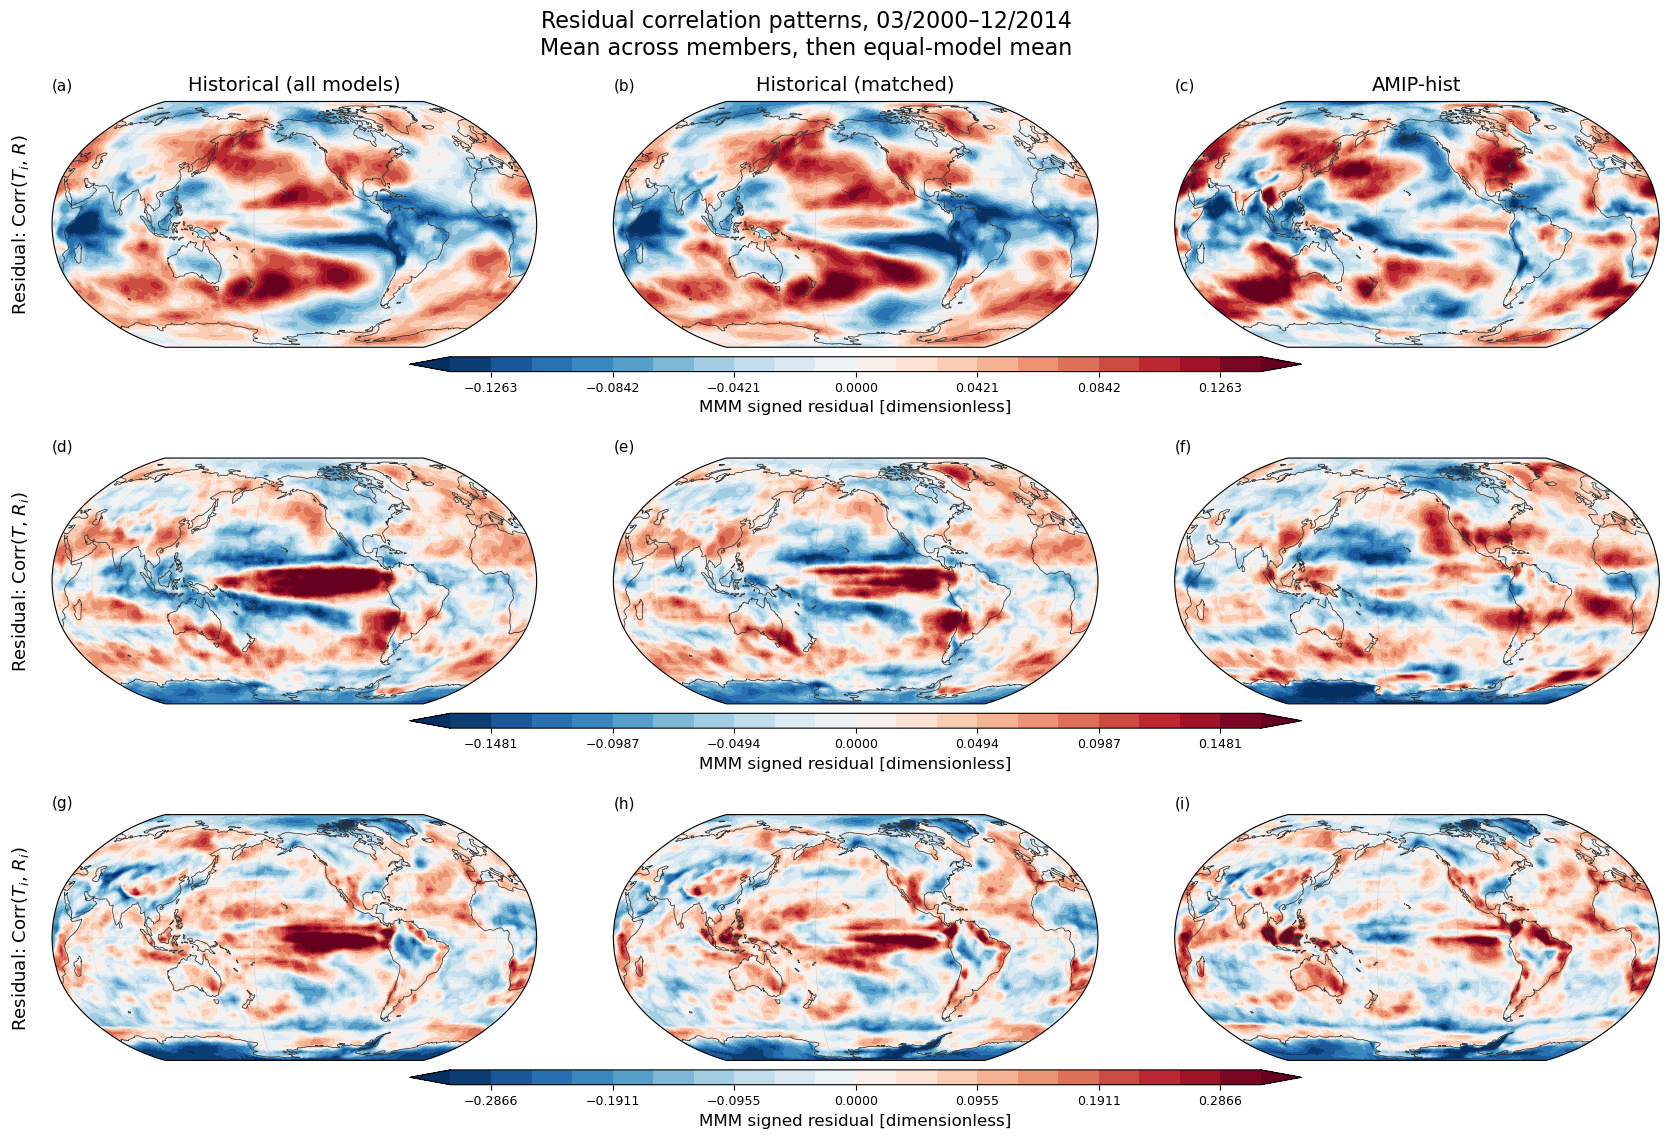

In [24]:
# %% 2. Arrange the saved residual MMMs into rows and columns, then plot.
# Requires overlap_MMM_residual_maps from the preceding averaging cell, plus
# lat and lon on that same grid. No member maps, new fits, or observations needed.
residual_grid_experiments = ["historical", "historical_matched", "amip_hist"]
residual_grid_quantities = ["corr_Ti_R", "corr_T_Ri", "corr_Ti_Ri"]

# Your corr_RTi / corr_TRi / corr_TiRi correspond to these stored keys.
# Array order is (diagnostic row, experiment column, lat, lon).
# The saved MMMs already average members first, then give each model one vote.
residual_grid_maps = np.stack([
    np.stack([np.ma.asarray(overlap_MMM_residual_maps[experiment][quantity], dtype=float).filled(np.nan)
              for experiment in residual_grid_experiments])
    for quantity in residual_grid_quantities
])

# Optional DISPLAY mask: True/1 keeps a cell; False/0/NaN hides it. For example,
# substitute your ocean-only or nonpolar mask. Apply before choosing color limits
# so automatic scales describe only the displayed cells. This does not refit the
# residuals, change their stored values, or recompute either level of averaging.
residual_display_mask = None
if residual_display_mask is not None:
    mask = np.ma.asarray(residual_display_mask, dtype=float).filled(np.nan)
    if mask.shape != residual_grid_maps.shape[-2:]:
        raise ValueError("The display mask must have shape (lat, lon).")
    keep = np.isfinite(mask) & (mask != 0)
    residual_grid_maps = np.where(keep[None, None, :, :], residual_grid_maps, np.nan)

# One symmetric color scale per ROW, shared across all three experiment columns.
# None chooses each row's 98th percentile of absolute displayed residuals.
# Set [0.2, 0.2, 0.2], for example, for a common fixed scale across all nine maps;
# this is a display choice, not a claim about the magnitude of your actual data.
residual_vlims = None
residual_cmap = "RdBu_r"                 # Or "cmr.fusion_r" after importing cmasher.
residual_robust_masks = None            # Do not reuse the original correlation/covariance masks.

fig_residual_grid, axes_residual_grid = plot_3x3_residual_maps(
    maps=residual_grid_maps, lat=lat, lon=lon,
    row_titles=[r"Residual: Corr($T_i$, $R$)", r"Residual: Corr($T$, $R_i$)",
                r"Residual: Corr($T_i$, $R_i$)"],
    column_titles=["Historical (all models)", "Historical (matched)", "AMIP-hist"],
    colorbar_labels=["MMM signed residual [dimensionless]"] * 3,
    figure_title="Residual correlation patterns, 03/2000–12/2014\nMean across members, then equal-model mean",
    central_longitude=210, cmaps=residual_cmap, vlims=residual_vlims,
    robust_percentile=98, number_of_levels=21, plot_method="contourf",
    robust_masks=residual_robust_masks, overlay_style="stipple", stipple_stride=2, stipple_size=3.,
    # savepath="./plots/residual_MMM_grid.png",
)
plt.show()

# These are mean SIGNED residuals: disagreement can cancel when averaged.
# Positive means above each member's fitted gain*obs + offset, not necessarily
# above the observed correlation itself. No original-map bias is added back.


In [25]:
residual_quantities

['corr_Ti_Ri',
 'corr_T_Ri',
 'corr_Ti_R',
 'sigma_Ti',
 'sigma_Ri',
 'cov_Zi_R',
 'cov_Ti_R',
 'cov_T_Qi',
 'cov_T_Ri',
 'cov_Zi_Ri',
 'cov_Ti_Qi',
 'cov_Ti_Ri']

Saved: data/maps_2000_2014_covImp/bias/residual_space_MMM_grid.png


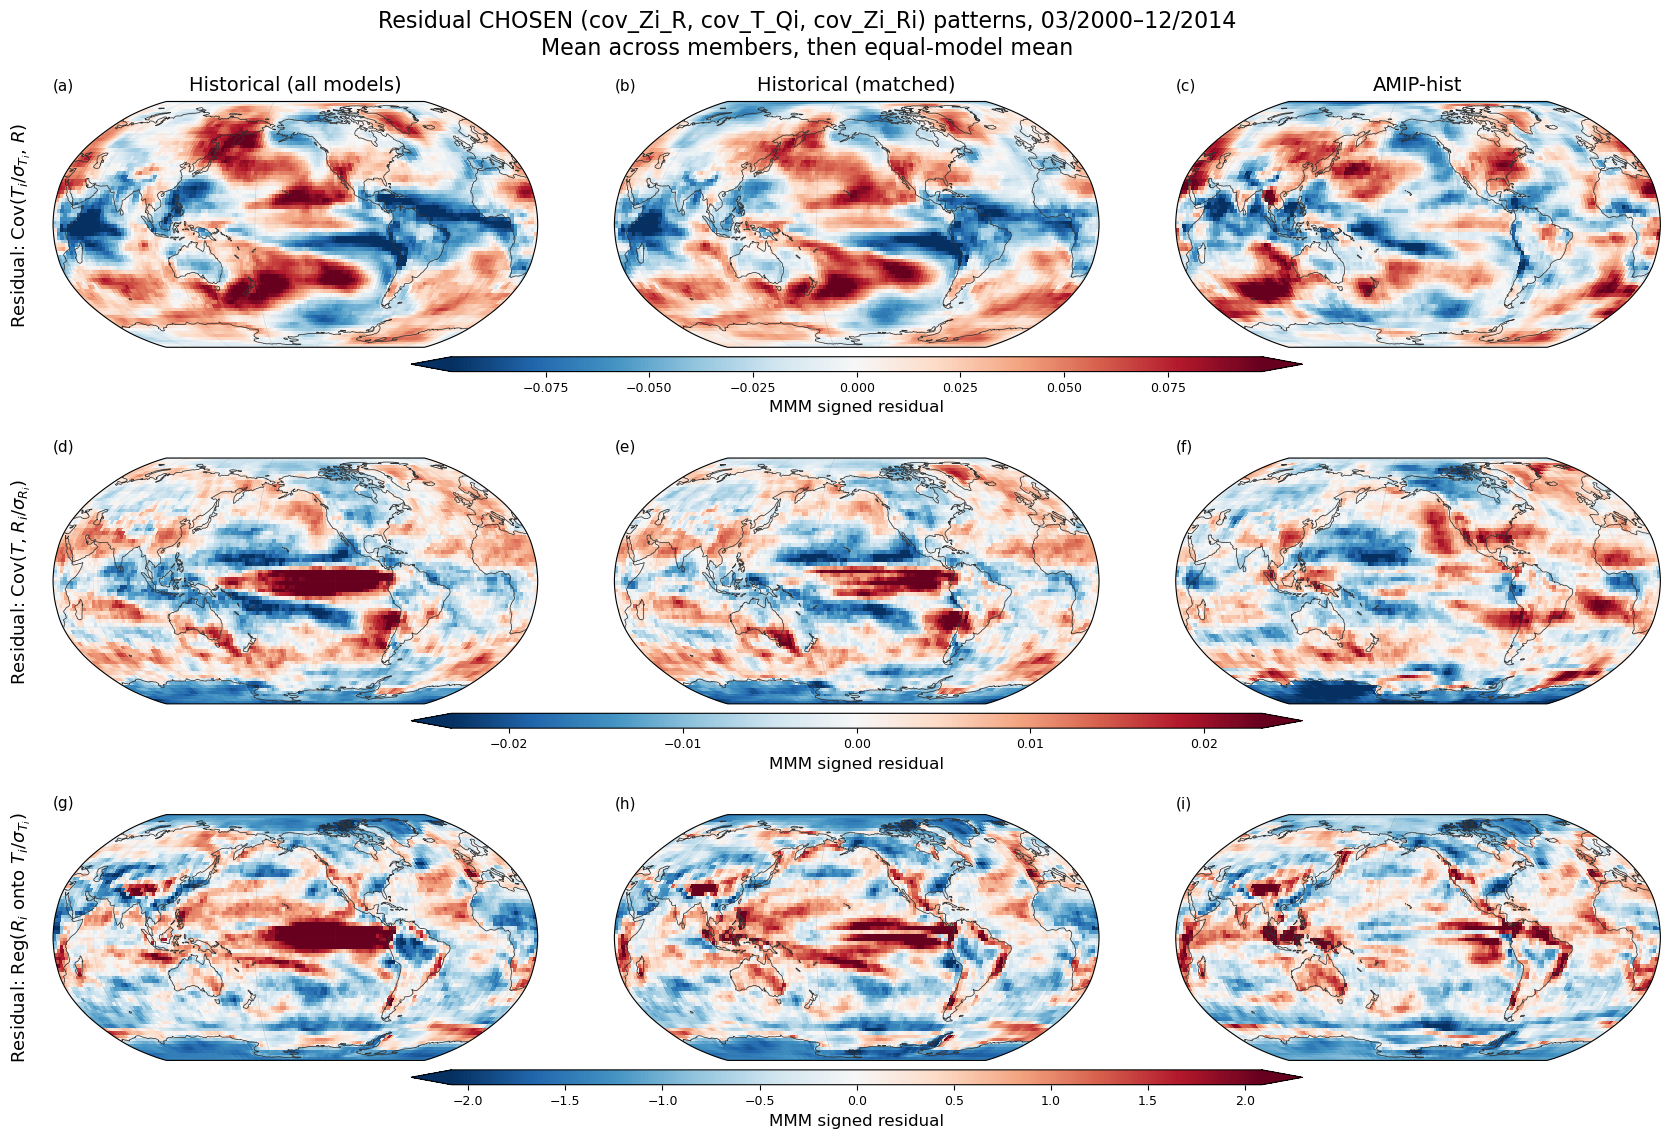

In [27]:
# %% 2. Arrange the saved residual MMMs into rows and columns, then plot.
# Requires overlap_MMM_residual_maps from the preceding averaging cell, plus
# lat and lon on that same grid. No member maps, new fits, or observations needed.
residual_grid_experiments = ["historical", "historical_matched", "amip_hist"]
residual_grid_quantities = ["cov_Zi_R", "cov_T_Qi", "cov_Zi_Ri"]

# Your corr_RTi / corr_TRi / corr_TiRi correspond to these stored keys.
# Array order is (diagnostic row, experiment column, lat, lon).
# The saved MMMs already average members first, then give each model one vote.
residual_grid_maps = np.stack([
    np.stack([np.ma.asarray(overlap_MMM_residual_maps[experiment][quantity], dtype=float).filled(np.nan)
              for experiment in residual_grid_experiments])
    for quantity in residual_grid_quantities
])

# Optional DISPLAY mask: True/1 keeps a cell; False/0/NaN hides it. For example,
# substitute your ocean-only or nonpolar mask. Apply before choosing color limits
# so automatic scales describe only the displayed cells. This does not refit the
# residuals, change their stored values, or recompute either level of averaging.
residual_display_mask = None
if residual_display_mask is not None:
    mask = np.ma.asarray(residual_display_mask, dtype=float).filled(np.nan)
    if mask.shape != residual_grid_maps.shape[-2:]:
        raise ValueError("The display mask must have shape (lat, lon).")
    keep = np.isfinite(mask) & (mask != 0)
    residual_grid_maps = np.where(keep[None, None, :, :], residual_grid_maps, np.nan)

# One symmetric color scale per ROW, shared across all three experiment columns.
# None chooses each row's 98th percentile of absolute displayed residuals.
# Set [0.2, 0.2, 0.2], for example, for a common fixed scale across all nine maps;
# this is a display choice, not a claim about the magnitude of your actual data.
residual_vlims = None
residual_cmap = "RdBu_r"                 # Or "cmr.fusion_r" after importing cmasher.
residual_robust_masks = None            # Do not reuse the original correlation/covariance masks.

fig_residual_grid, axes_residual_grid = plot_3x3_residual_maps(
    maps=residual_grid_maps, lat=lat, lon=lon,
    row_titles=[r"Residual: Cov($T_i$/$\sigma_{T_i}$, $R$)", r"Residual: Cov($T$, $R_i$/$\sigma_{R_i}$)",
                r"Residual: Reg($R_i$ onto $T_i$/$\sigma_{T_i}$)"],
    column_titles=["Historical (all models)", "Historical (matched)", "AMIP-hist"],
    colorbar_labels=["MMM signed residual"] * 3,
    figure_title="Residual CHOSEN (cov_Zi_R, cov_T_Qi, cov_Zi_Ri) patterns, 03/2000–12/2014\nMean across members, then equal-model mean",
    central_longitude=210, cmaps=residual_cmap, vlims=residual_vlims,
    robust_percentile=98, number_of_levels=21, plot_method="pcolormesh",
    robust_masks=residual_robust_masks, overlay_style="stipple", stipple_stride=2, stipple_size=3.,
    savepath="./data/maps_2000_2014_covImp/bias/residual_space_MMM_grid.png",
)
plt.show()

# These are mean SIGNED residuals: disagreement can cancel when averaged.
# Positive means above each member's fitted gain*obs + offset, not necessarily
# above the observed correlation itself. No original-map bias is added back.
